## Run a pipeline

### Minimal Pipeline Execution: Runs in just **3 lines of code**

```python
from paidiverpy.pipeline import Pipeline
pipeline = Pipeline(config_file_path="../config_files/config_benthic.yml")
pipeline.run()
```

### This is the configuration file:


```yaml
general:
  sample_data: "benthic_ifdo"
  output_path: "./output"
  n_jobs: 8
  sampling:
    - mode: "fixed"
      params:
        value: 5
  convert:
    - mode: "bits"
      params:
        output_bits: 8
steps:
  - colour:
      name: "colour_correction"
      mode: "grayscale"

  - sampling:
      name: "datetime"
      mode: "datetime"
      params:
        min: "2016-05-11 04:14:00"
        max: "2016-05-11 09:27:00"

  - colour:
      name: "colour_correction"
      mode: "gaussian_blur"
      params:
        sigma: 1.0

  - colour:
      name: "sharpen"
      mode: "sharpen"
      params:
        alpha: 1.5
        beta: -0.5

  - colour:
      name: "contrast"
      mode: "contrast"
```

### Sample data

This configuration file uses a part of our example data:

```yaml
general:
  sample_data: "benthic_ifdo"
```

In this case, it will download the data automatically. But you can also do it manually:

In [1]:
from paidiverpy.utils.data import PaidiverpyData

data = PaidiverpyData()
data.load("benthic_ifdo")

{'input_path': '/home/tobfer/.paidiverpy_cache/benthic_ifdo/images',
 'metadata_path': '/home/tobfer/.paidiverpy_cache/benthic_ifdo/metadata/metadata_benthic_ifdo.json',
 'metadata_type': 'IFDO',
 'image_open_args': 'JPG'}

## Running the code

In [2]:
%load_ext autoreload
%autoreload 2
from paidiverpy.pipeline import Pipeline

In [3]:
pipeline = Pipeline(config_file_path="../config_files/config_benthic.yml")

In [4]:
# See the pipeline steps. Click in a step to see more information about it
pipeline

In [5]:
# See the pipeline steps in json format
pipeline.config

{
    "general": {
        "name": "raw",
        "step_name": "open",
        "sample_data": "benthic_csv",
        "input_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/images",
        "output_path": "output",
        "metadata_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/metadata_benthic_csv.csv",
        "metadata_type": "CSV_FILE",
        "image_open_args": "PNG",
        "append_data_to_metadata": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/appended_metadata_benthic_csv.csv",
        "n_jobs": 1,
        "track_changes": true,
        "sampling": [
            {
                "name": "sampling",
                "step_name": "sampling",
                "test": false,
                "params": {
                    "value": 20,
                    "raise_error": false
                },
                "mode": "fixed"
            }
        ]
    },
    "steps": [
        {
            "name": "colour_correction",
            "step_name": "colour",
            "test": false,
            "params": {
                "method": "opencv",
                "invert_colours": false,
                "raise_error": false
            },
            "mode": "grayscale"
        },
        {
            "name": "datetime",
            "step_name": "sampling",
            "test": false,
            "params": {
                "min": "2018-06-11 04:14:00",
                "max": "2018-06-11 04:20:00",
                "raise_error": false
            },
            "mode": "datetime"
        },
        {
            "name": "overlapping",
            "step_name": "sampling",
            "test": false,
            "params": {
                "omega": 57.0,
                "theta": 40.0,
                "threshold": 0.5,
                "camera_distance": 1.12,
                "raise_error": false
            },
            "mode": "overlapping"
        },
        {
            "name": "colour_correction",
            "step_name": "colour",
            "test": false,
            "params": {
                "sigma": 1.0,
                "raise_error": false
            },
            "mode": "gaussian_blur"
        },
        {
            "name": "sharpen",
            "step_name": "colour",
            "test": false,
            "params": {
                "alpha": 1.5,
                "beta": -0.5,
                "raise_error": false
            },
            "mode": "sharpen"
        },
        {
            "name": "contrast",
            "step_name": "colour",
            "test": false,
            "params": {
                "method": "clahe",
                "clip_limit": 0.01,
                "gamma_value": 0.5,
                "raise_error": false
            },
            "mode": "contrast"
        }
    ]
}

In [6]:
pipeline.metadata

,ID,image-filename,XResolution,YResolution,ExposureTime,FNumber,ISO,image-datetime,MaxApertureValue,WhiteBalance,...,speed_of_sound_m_s,temperature_c,positioning_ok,attitude_ok,depth_ok,altitude_ok,X,phototime,flag,point
0,430.0,20180611041421.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:14:21,2.828427,FLASH,...,1545.388,1.5059,1,1,1,1,NaN,2018-06-11 04:14:21,0,POINT (-153.60531587 11.25172554)
1,431.0,20180611041431.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:14:31,2.828427,FLASH,...,1545.447,1.5236,1,1,1,1,NaN,2018-06-11 04:14:31,0,POINT (-153.60531372 11.25171832)
2,432.0,20180611041441.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:14:41,2.828427,FLASH,...,1545.452,1.5234,1,1,1,1,NaN,2018-06-11 04:14:41,0,POINT (-153.60531259 11.2517135)
3,433.0,20180611041451.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:14:51,2.828427,FLASH,...,1545.363,1.4911,1,1,1,1,NaN,2018-06-11 04:14:51,0,POINT (-153.60531313 11.25170837)
4,434.0,20180611041501.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:01,2.828427,FLASH,...,1545.324,1.4747,1,1,1,1,NaN,2018-06-11 04:15:01,0,POINT (-153.60531414 11.25170299)
5,435.0,20180611041511.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:11,2.828427,FLASH,...,1545.298,1.4635,1,1,1,1,NaN,2018-06-11 04:15:11,0,POINT (-153.60531664 11.25169768)
6,436.0,20180611041521.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:21,2.828427,FLASH,...,1545.315,1.4697,1,1,1,1,NaN,2018-06-11 04:15:21,0,POINT (-153.6053176 11.25169125)
7,437.0,20180611041531.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:31,2.828427,FLASH,...,1545.326,1.4727,1,1,1,1,NaN,2018-06-11 04:15:31,0,POINT (-153.60532046 11.25168357)
8,438.0,20180611041541.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:41,2.828427,FLASH,...,1545.266,1.4532,1,1,1,1,NaN,2018-06-11 04:15:41,0,POINT (-153.60532129 11.25167559)
9,439.0,20180611041551.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:51,2.828427,FLASH,...,1545.263,1.4512,1,1,1,1,NaN,2018-06-11 04:15:51,0,POINT (-153.60532147 11.25166737)


In [7]:
# Run the pipeline
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2025-06-09 14:29:49 | Processing images using 1 cores
☁ paidiverpy ☁  |       INFO | 2025-06-09 14:29:49 | Running step 0: raw - OpenLayer
☁ paidiverpy ☁  |       INFO | 2025-06-09 14:29:49 | Number of images to be removed: 29. Total number of images: 49


Open Images: 100%|█████████████████████████████████| 20/20 [00:00<00:00, 289.27it/s]


☁ paidiverpy ☁  |       INFO | 2025-06-09 14:29:49 | Step 0 completed
☁ paidiverpy ☁  |       INFO | 2025-06-09 14:29:49 | Running step 1: colour_correction - ColourLayer


Processing images: 100%|██████████████████████████| 20/20 [00:00<00:00, 8359.35it/s]


☁ paidiverpy ☁  |       INFO | 2025-06-09 14:29:50 | Step 1 completed
☁ paidiverpy ☁  |       INFO | 2025-06-09 14:29:50 | Running step 2: datetime - SamplingLayer
☁ paidiverpy ☁  |       INFO | 2025-06-09 14:29:50 | Number of images to be removed: 9. Total number of images: 20
☁ paidiverpy ☁  |       INFO | 2025-06-09 14:29:50 | Step 2 completed
☁ paidiverpy ☁  |       INFO | 2025-06-09 14:29:50 | Running step 3: overlapping - SamplingLayer
☁ paidiverpy ☁  |       INFO | 2025-06-09 14:29:50 | Number of images to be removed: 2. Total number of images: 11
☁ paidiverpy ☁  |       INFO | 2025-06-09 14:29:50 | Step 3 completed
☁ paidiverpy ☁  |       INFO | 2025-06-09 14:29:50 | Running step 4: colour_correction - ColourLayer


...

☁ paidiverpy ☁  |       INFO | 2025-06-09 14:29:51 | Running step 5: sharpen - ColourLayer


Processing images: 100%|████████████████████████████| 9/9 [00:00<00:00, 1398.83it/s]

☁ paidiverpy ☁  |       INFO | 2025-06-09 14:29:51 | Step 5 completed
☁ paidiverpy ☁  |       INFO | 2025-06-09 14:29:51 | Running step 6: contrast - ColourLayer



Processing images: 100%|█████████████████████████████| 9/9 [00:00<00:00, 216.06it/s]


☁ paidiverpy ☁  |       INFO | 2025-06-09 14:29:51 | Step 6 completed


In [8]:
pipeline.metadata

,image-filename,ID,XResolution,YResolution,ExposureTime,FNumber,ISO,image-datetime,MaxApertureValue,WhiteBalance,...,TRcornerlong,TRcornerlat,TLcornerlong,TLcornerlat,BLcornerlong,BLcornerlat,BRcornerlong,BRcornerlat,overlap,polygon_m
0,20180611041421.png,430.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:14:21,2.828427,FLASH,...,-153.605307,11.251713,-153.605307,11.251738,-153.605324,11.251739,-153.605325,11.251713,0,POLYGON ((-153.60530730838863 11.2517125679763...
1,20180611041521.png,436.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:21,2.828427,FLASH,...,-153.605309,11.251678,-153.605308,11.251705,-153.605327,11.251705,-153.605327,11.251678,0,POLYGON ((-153.60530868210603 11.2516778018813...
2,20180611041531.png,437.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:31,2.828427,FLASH,...,-153.605312,11.251671,-153.605312,11.251696,-153.605329,11.251696,-153.605329,11.251671,1,POLYGON ((-153.60532918833948 11.2516707067058...
3,20180611041551.png,439.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:51,2.828427,FLASH,...,-153.605313,11.251654,-153.605313,11.251680,-153.605330,11.251680,-153.605330,11.251655,0,POLYGON ((-153.60531287424553 11.2516544199985...
4,20180611041641.png,444.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:16:41,2.828427,FLASH,...,-153.605312,11.251629,-153.605311,11.251655,-153.605329,11.251655,-153.605329,11.251629,0,POLYGON ((-153.60531157256716 11.2516293035685...
5,20180611041801.png,452.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:18:01,2.828427,FLASH,...,-153.605299,11.251615,-153.605299,11.251641,-153.605316,11.251641,-153.605317,11.251615,0,POLYGON ((-153.60529932432337 11.2516151158048...
6,20180611041821.png,454.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:18:21,2.828427,FLASH,...,-153.605281,11.251619,-153.605281,11.251647,-153.605300,11.251647,-153.605300,11.251619,0,POLYGON ((-153.6052814564868 11.25161910801365...
7,20180611041841.png,456.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:18:41,2.828427,FLASH,...,-153.605268,11.251624,-153.605268,11.251651,-153.605286,11.251652,-153.605287,11.251624,0,POLYGON ((-153.60526798471008 11.2516238013981...
8,20180611041851.png,457.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:18:51,2.828427,FLASH,...,-153.605263,11.251625,-153.605263,11.251652,-153.605281,11.251652,-153.605281,11.251625,1,POLYGON ((-153.60526315869816 11.2516251992590...
9,20180611041921.png,460.0,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:19:21,2.828427,FLASH,...,-153.605239,11.251625,-153.605239,11.251651,-153.605257,11.251651,-153.605257,11.251625,0,POLYGON ((-153.60523920480418 11.2516248686363...


Step: raw
Image: [[[179 189 164 255]
  [178 189 165 255]
  [180 190 168 255]
  ...
  [209 206 161 255]
  [210 205 161 255]
  [210 206 164 255]]

 [[181 190 166 255]
  [180 189 165 255]
  [179 190 169 255]
  ...
  [210 204 159 255]
  [211 206 162 255]
  [212 206 161 255]]

 [[182 190 169 255]
  [180 189 169 255]
  [183 190 168 255]
  ...
  [209 206 163 255]
  [210 204 161 255]
  [211 207 163 255]]

 ...

 [[188 190 167 255]
  [187 189 167 255]
  [193 191 167 255]
  ...
  [216 209 167 255]
  [216 210 169 255]
  [214 209 169 255]]

 [[185 188 166 255]
  [189 189 166 255]
  [190 191 167 255]
  ...
  [215 208 169 255]
  [214 209 171 255]
  [215 209 168 255]]

 [[186 189 167 255]
  [190 190 167 255]
  [192 189 167 255]
  ...
  [215 208 167 255]
  [215 208 168 255]
  [214 209 170 255]]]
Image: [[[195 203 179 255]
  [195 204 180 255]
  [195 204 179 255]
  ...
  [211 208 171 255]
  [209 209 170 255]
  [210 208 171 255]]

 [[197 204 182 255]
  [197 202 179 255]
  [195 202 180 255]
  ...
  [210 209 171 255]
  [210 208 171 255]
  [212 210 173 255]]

 [[196 204 181 255]
  [195 203 180 255]
  [198 203 181 255]
  ...
  [211 208 173 255]
  [211 208 171 255]
  [211 209 171 255]]

 ...

 [[192 195 172 255]
  [195 197 175 255]
  [198 198 173 255]
  ...
  [203 203 173 255]
  [203 202 171 255]
  [203 203 173 255]]

 [[193 195 173 255]
  [193 195 173 255]
  [197 196 174 255]
  ...
  [202 201 171 255]
  [203 202 172 255]
  [204 204 174 255]]

 [[194 196 175 255]
  [195 196 174 255]
  [196 196 172 255]
  ...
  [202 202 173 255]
  [203 202 173 255]
  [202 202 173 255]]]
Image: [[[197 207 185 255]
  [197 206 183 255]
  [195 206 183 255]
  ...
  [208 208 171 255]
  [209 209 173 255]
  [211 209 173 255]]

 [[197 208 187 255]
  [197 208 187 255]
  [196 205 184 255]
  ...
  [210 209 175 255]
  [211 209 174 255]
  [210 210 175 255]]

 [[199 208 187 255]
  [198 207 187 255]
  [199 207 187 255]
  ...
  [211 211 175 255]
  [211 209 176 255]
  [211 210 176 255]]

 ...

 [[197 199 177 255]
  [197 200 178 255]
  [199 199 177 255]
  ...
  [204 204 178 255]
  [204 205 175 255]
  [203 205 177 255]]

 [[197 198 176 255]
  [196 199 178 255]
  [198 198 177 255]
  ...
  [202 202 174 255]
  [204 204 176 255]
  [204 204 176 255]]

 [[196 198 176 255]
  [198 199 177 255]
  [199 198 176 255]
  ...
  [202 203 175 255]
  [204 203 176 255]
  [203 204 179 255]]]
Image: [[[184 197 179 255]
  [183 197 178 255]
  [181 196 178 255]
  ...
  [202 207 173 255]
  [204 207 174 255]
  [202 207 174 255]]

 [[179 195 178 255]
  [182 196 178 255]
  [183 195 179 255]
  ...
  [204 206 174 255]
  [203 207 176 255]
  [205 207 175 255]]

 [[181 195 180 255]
  [185 197 182 255]
  [185 197 182 255]
  ...
  [202 207 175 255]
  [204 207 175 255]
  [204 207 177 255]]

 ...

 [[188 194 173 255]
  [187 193 175 255]
  [191 195 174 255]
  ...
  [196 199 171 255]
  [194 197 174 255]
  [195 198 174 255]]

 [[185 192 174 255]
  [188 192 173 255]
  [192 192 175 255]
  ...
  [194 197 171 255]
  [195 198 174 255]
  [194 198 173 255]]

 [[187 193 175 255]
  [190 192 173 255]
  [190 194 172 255]
  ...
  [194 197 170 255]
  [194 196 173 255]
  [194 198 174 255]]]
Image: [[[143 165 153 255]
  [145 166 155 255]
  [149 168 158 255]
  ...
  [157 178 160 255]
  [155 177 160 255]
  [153 175 160 255]]

 [[144 165 153 255]
  [147 168 159 255]
  [146 166 156 255]
  ...
  [157 177 163 255]
  [156 177 161 255]
  [155 176 161 255]]

 [[144 166 157 255]
  [146 166 156 255]
  [147 167 156 255]
  ...
  [155 177 160 255]
  [156 177 163 255]
  [157 177 162 255]]

 ...

 [[164 176 165 255]
  [166 175 166 255]
  [174 179 167 255]
  ...
  [184 197 179 255]
  [188 198 182 255]
  [185 198 181 255]]

 [[163 171 163 255]
  [166 175 166 255]
  [173 177 165 255]
  ...
  [187 197 181 255]
  [186 197 180 255]
  [186 196 181 255]]

 [[165 174 164 255]
  [169 176 165 255]
  [175 177 165 255]
  ...
  [189 197 181 255]
  [185 197 181 255]
  [186 196 181 255]]]
Image: [[[ 87 118 112 255]
  [ 86 117 111 255]
  [ 93 122 115 255]
  ...
  [144 171 1
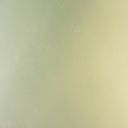
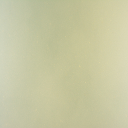
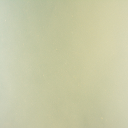
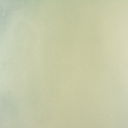
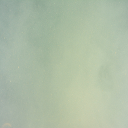
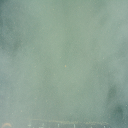
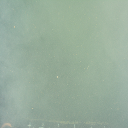
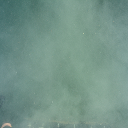
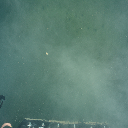
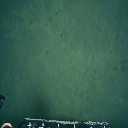
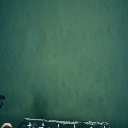
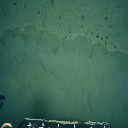
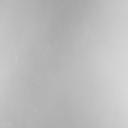
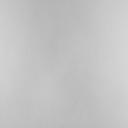
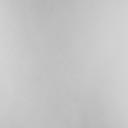
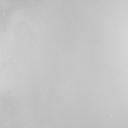
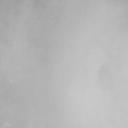
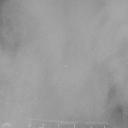
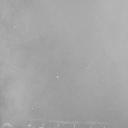
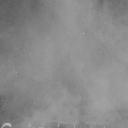
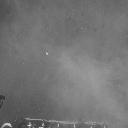
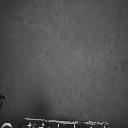
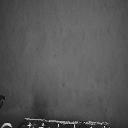
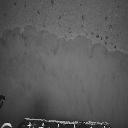
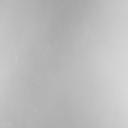
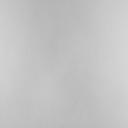
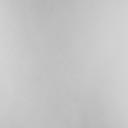
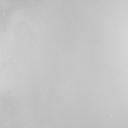
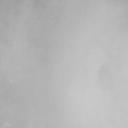
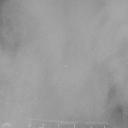
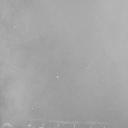
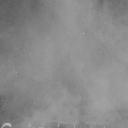
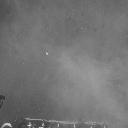
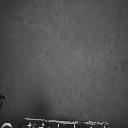
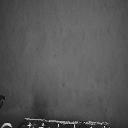
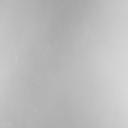
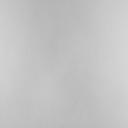
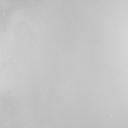
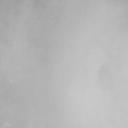
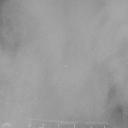
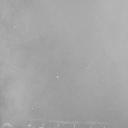
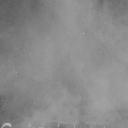
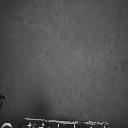
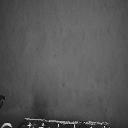
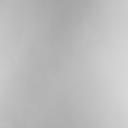
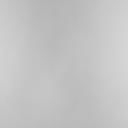
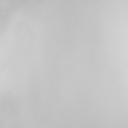
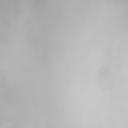
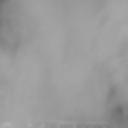
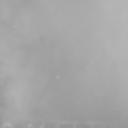
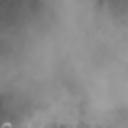
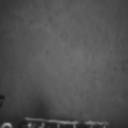
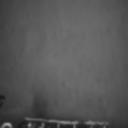
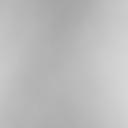
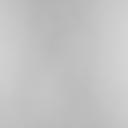
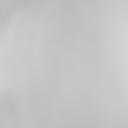
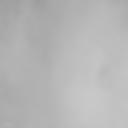
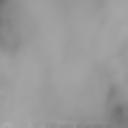
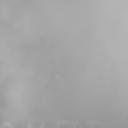
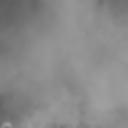
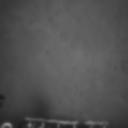
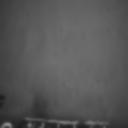
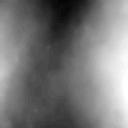
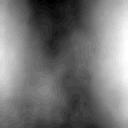
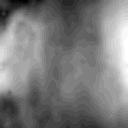
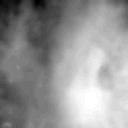
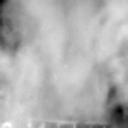
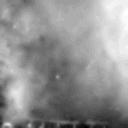
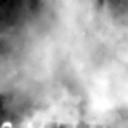
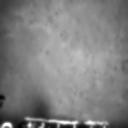
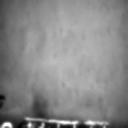

In [9]:
# See the images output
pipeline.images


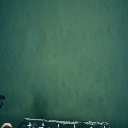
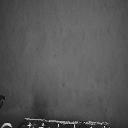
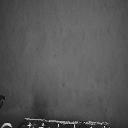

In [10]:
pipeline.images.show(image_number=10)

# Export Images to file

In [11]:
pipeline.save_images(image_format="png")

☁ paidiverpy ☁  |       INFO | 2025-06-09 14:29:52 | Saving images from step: last
☁ paidiverpy ☁  |       INFO | 2025-06-09 14:29:52 | Saving images
☁ paidiverpy ☁  |       INFO | 2025-06-09 14:29:52 | Images are saved to: output
